# A Quick Exploratory Data Analysis

### Skim through to get a feeling for the data
- How do the bike rental counts behave by the hour and day?
- Whats the variance like?

In [1]:
# Install packages not available by default on Colab
# !pip install ucimlrepo --quiet

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from ucimlrepo import fetch_ucirepo, list_available_datasets
 
bike_sharing = fetch_ucirepo(id=275) 

print(bike_sharing.metadata) 
print(bike_sharing.variables) 

{'uci_id': 275, 'name': 'Bike Sharing', 'repository_url': 'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/275/data.csv', 'abstract': 'This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.', 'area': 'Social Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 17389, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['cnt'], 'index_col': ['instant'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5W894', 'creators': ['Hadi Fanaee-T'], 'intro_paper': {'ID': 422, 'type': 'NATIVE', 'title': 'Event labeling combining ensemble detectors and background knowledge', 'authors': 'Hadi Fanaee-T, João Gama', 'venue': 'Progress

In [2]:
# data (as a pandas dataframe) 
X = bike_sharing.data.features 
y = bike_sharing.data.targets 

df = pd.concat([X,y], axis=1)
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


# Exploratory Data Analysis

1. Insepct the correlation of features/target set
2. Inspect the summary statistics 
3. Inspect histograms of counts vs features

## Correlation Matrix

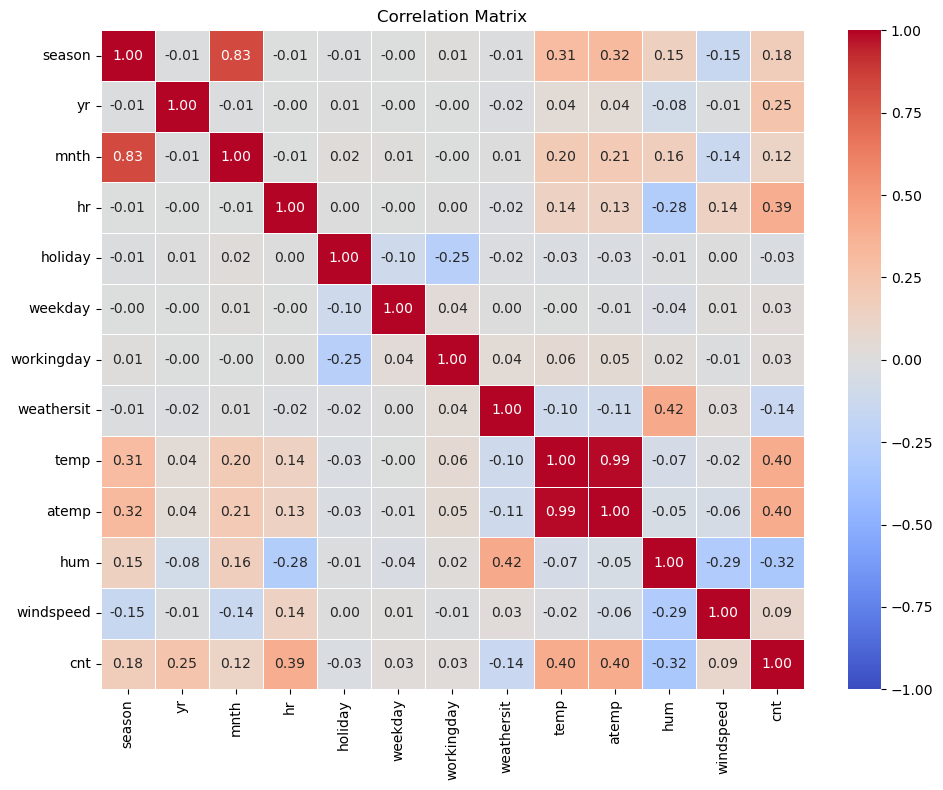

In [3]:
corr_matrix = df.drop(columns=['dteday']).corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

# Set title
plt.title('Correlation Matrix')

# Display the plot
plt.tight_layout()
plt.show()

## Summary Statistics vs Hour

- Compute various measures of "central tendency" and variation. 
- Recall that linear regression assumes Gaussian likelihood with fixed variance while Poisson regression assumes a Poisson likelihood which has Var=mean.

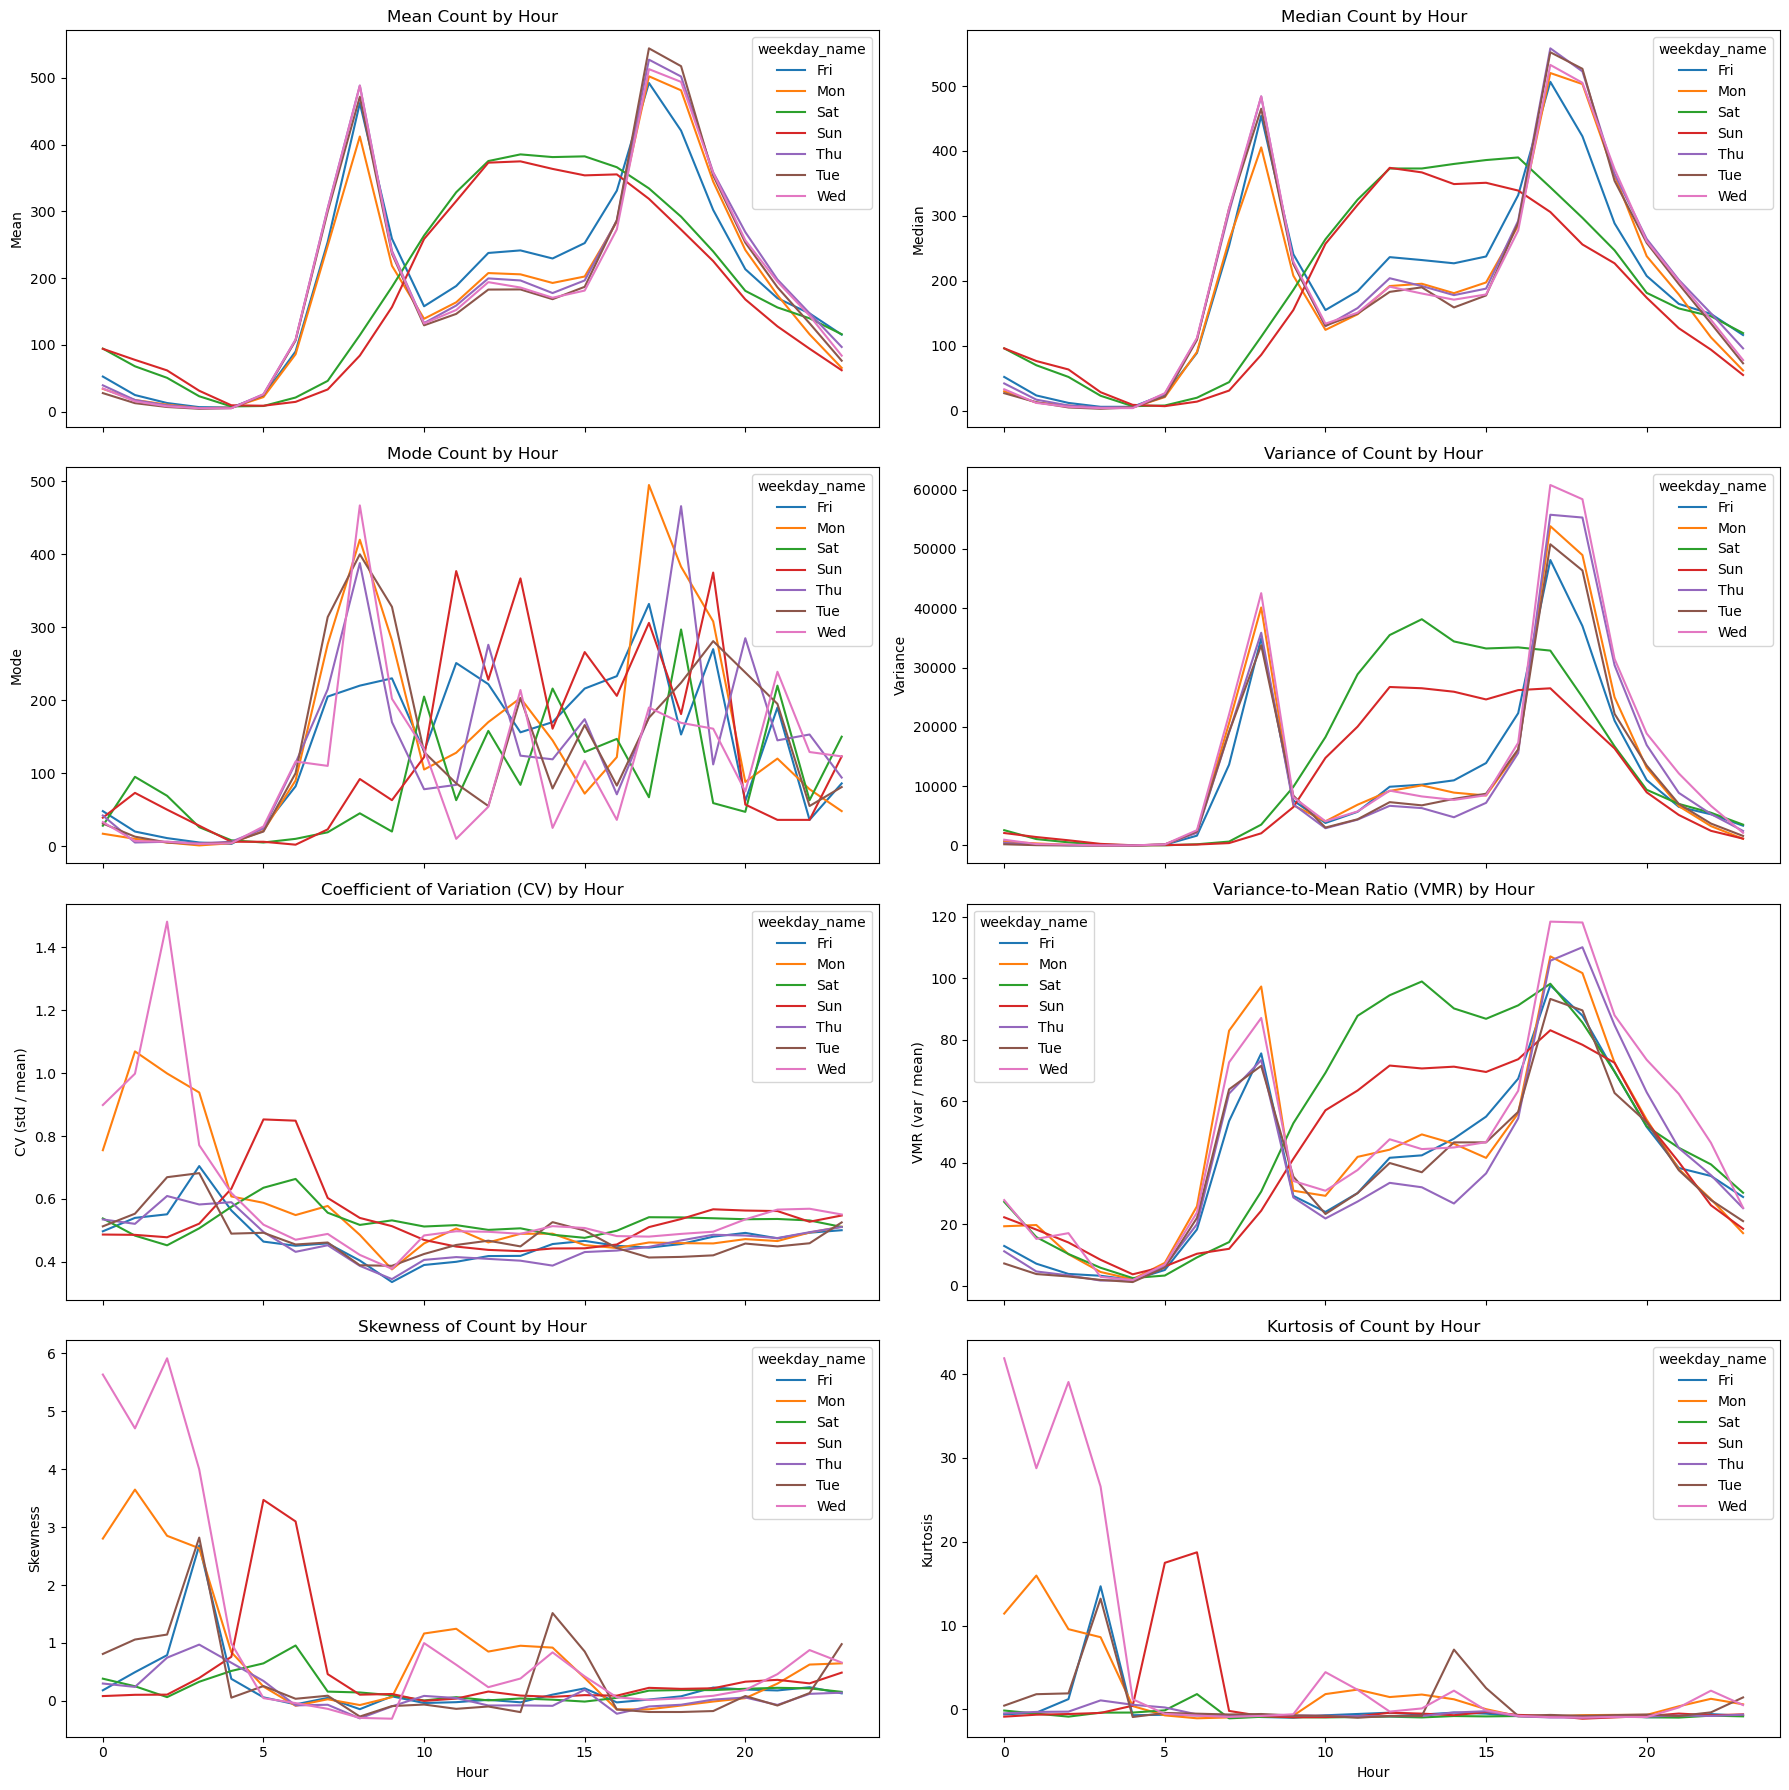

In [4]:
# Map integer weekday to weekday name
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
df['weekday_name'] = df['weekday'].map(weekday_map)

# Group by weekday name and hour
grouped = df.groupby(['weekday_name', 'hr'])['cnt']

# Compute base aggregates
summary = grouped.agg(
    mean='mean',
    median='median',
    var='var',
    std='std',
    max='max',
    min='min'
).reset_index()

# Mode (first mode per group)
mode = grouped.apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan).reset_index(name='mode')

# Skewness and kurtosis using pandas built-ins
skewness = grouped.skew().reset_index(name='skewness')
kurtosis = grouped.apply(lambda x: x.kurt()).reset_index(name='kurtosis')

# Merge mode, skewness, kurtosis
summary = summary.merge(mode, on=['weekday_name', 'hr'])
summary = summary.merge(skewness, on=['weekday_name', 'hr'])
summary = summary.merge(kurtosis, on=['weekday_name', 'hr'])

# Derived metrics
summary['cv'] = summary['std'] / summary['mean']
summary['vmr'] = summary['var'] / summary['mean']

# Pivot for plotting
avg_pivot    = summary.pivot(index='hr', columns='weekday_name', values='mean')
median_pivot = summary.pivot(index='hr', columns='weekday_name', values='median')
mode_pivot   = summary.pivot(index='hr', columns='weekday_name', values='mode')
var_pivot    = summary.pivot(index='hr', columns='weekday_name', values='var')
cv_pivot     = summary.pivot(index='hr', columns='weekday_name', values='cv')
vmr_pivot    = summary.pivot(index='hr', columns='weekday_name', values='vmr')
skew_pivot   = summary.pivot(index='hr', columns='weekday_name', values='skewness')
kurt_pivot   = summary.pivot(index='hr', columns='weekday_name', values='kurtosis')

# Plotting 4x2 grid
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 18), sharex=True)
axes = axes.flatten()

avg_pivot.plot(ax=axes[0], title='Mean Count by Hour')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Mean')

median_pivot.plot(ax=axes[1], title='Median Count by Hour')
axes[1].set_xlabel('Hour'); axes[1].set_ylabel('Median')

mode_pivot.plot(ax=axes[2], title='Mode Count by Hour')
axes[2].set_xlabel('Hour'); axes[2].set_ylabel('Mode')

var_pivot.plot(ax=axes[3], title='Variance of Count by Hour')
axes[3].set_xlabel('Hour'); axes[3].set_ylabel('Variance')

cv_pivot.plot(ax=axes[4], title='Coefficient of Variation (CV) by Hour')
axes[4].set_xlabel('Hour'); axes[4].set_ylabel('CV (std / mean)')

vmr_pivot.plot(ax=axes[5], title='Variance-to-Mean Ratio (VMR) by Hour')
axes[5].set_xlabel('Hour'); axes[5].set_ylabel('VMR (var / mean)')

skew_pivot.plot(ax=axes[6], title='Skewness of Count by Hour')
axes[6].set_xlabel('Hour'); axes[6].set_ylabel('Skewness')

kurt_pivot.plot(ax=axes[7], title='Kurtosis of Count by Hour')
axes[7].set_xlabel('Hour'); axes[7].set_ylabel('Kurtosis')

plt.tight_layout()
plt.show()


## Insepction
- Pronounced difference in rates for weekdays vs. weekends
- Holiday likely has a similar effect (changing the distribution to match non-workday)
- Variance is certainly not constant, nor is it equal to the mean (though it does follow the mean).
- Mode computation is funky
- Skewness and Kurtosis?

## Histograming counts by feature

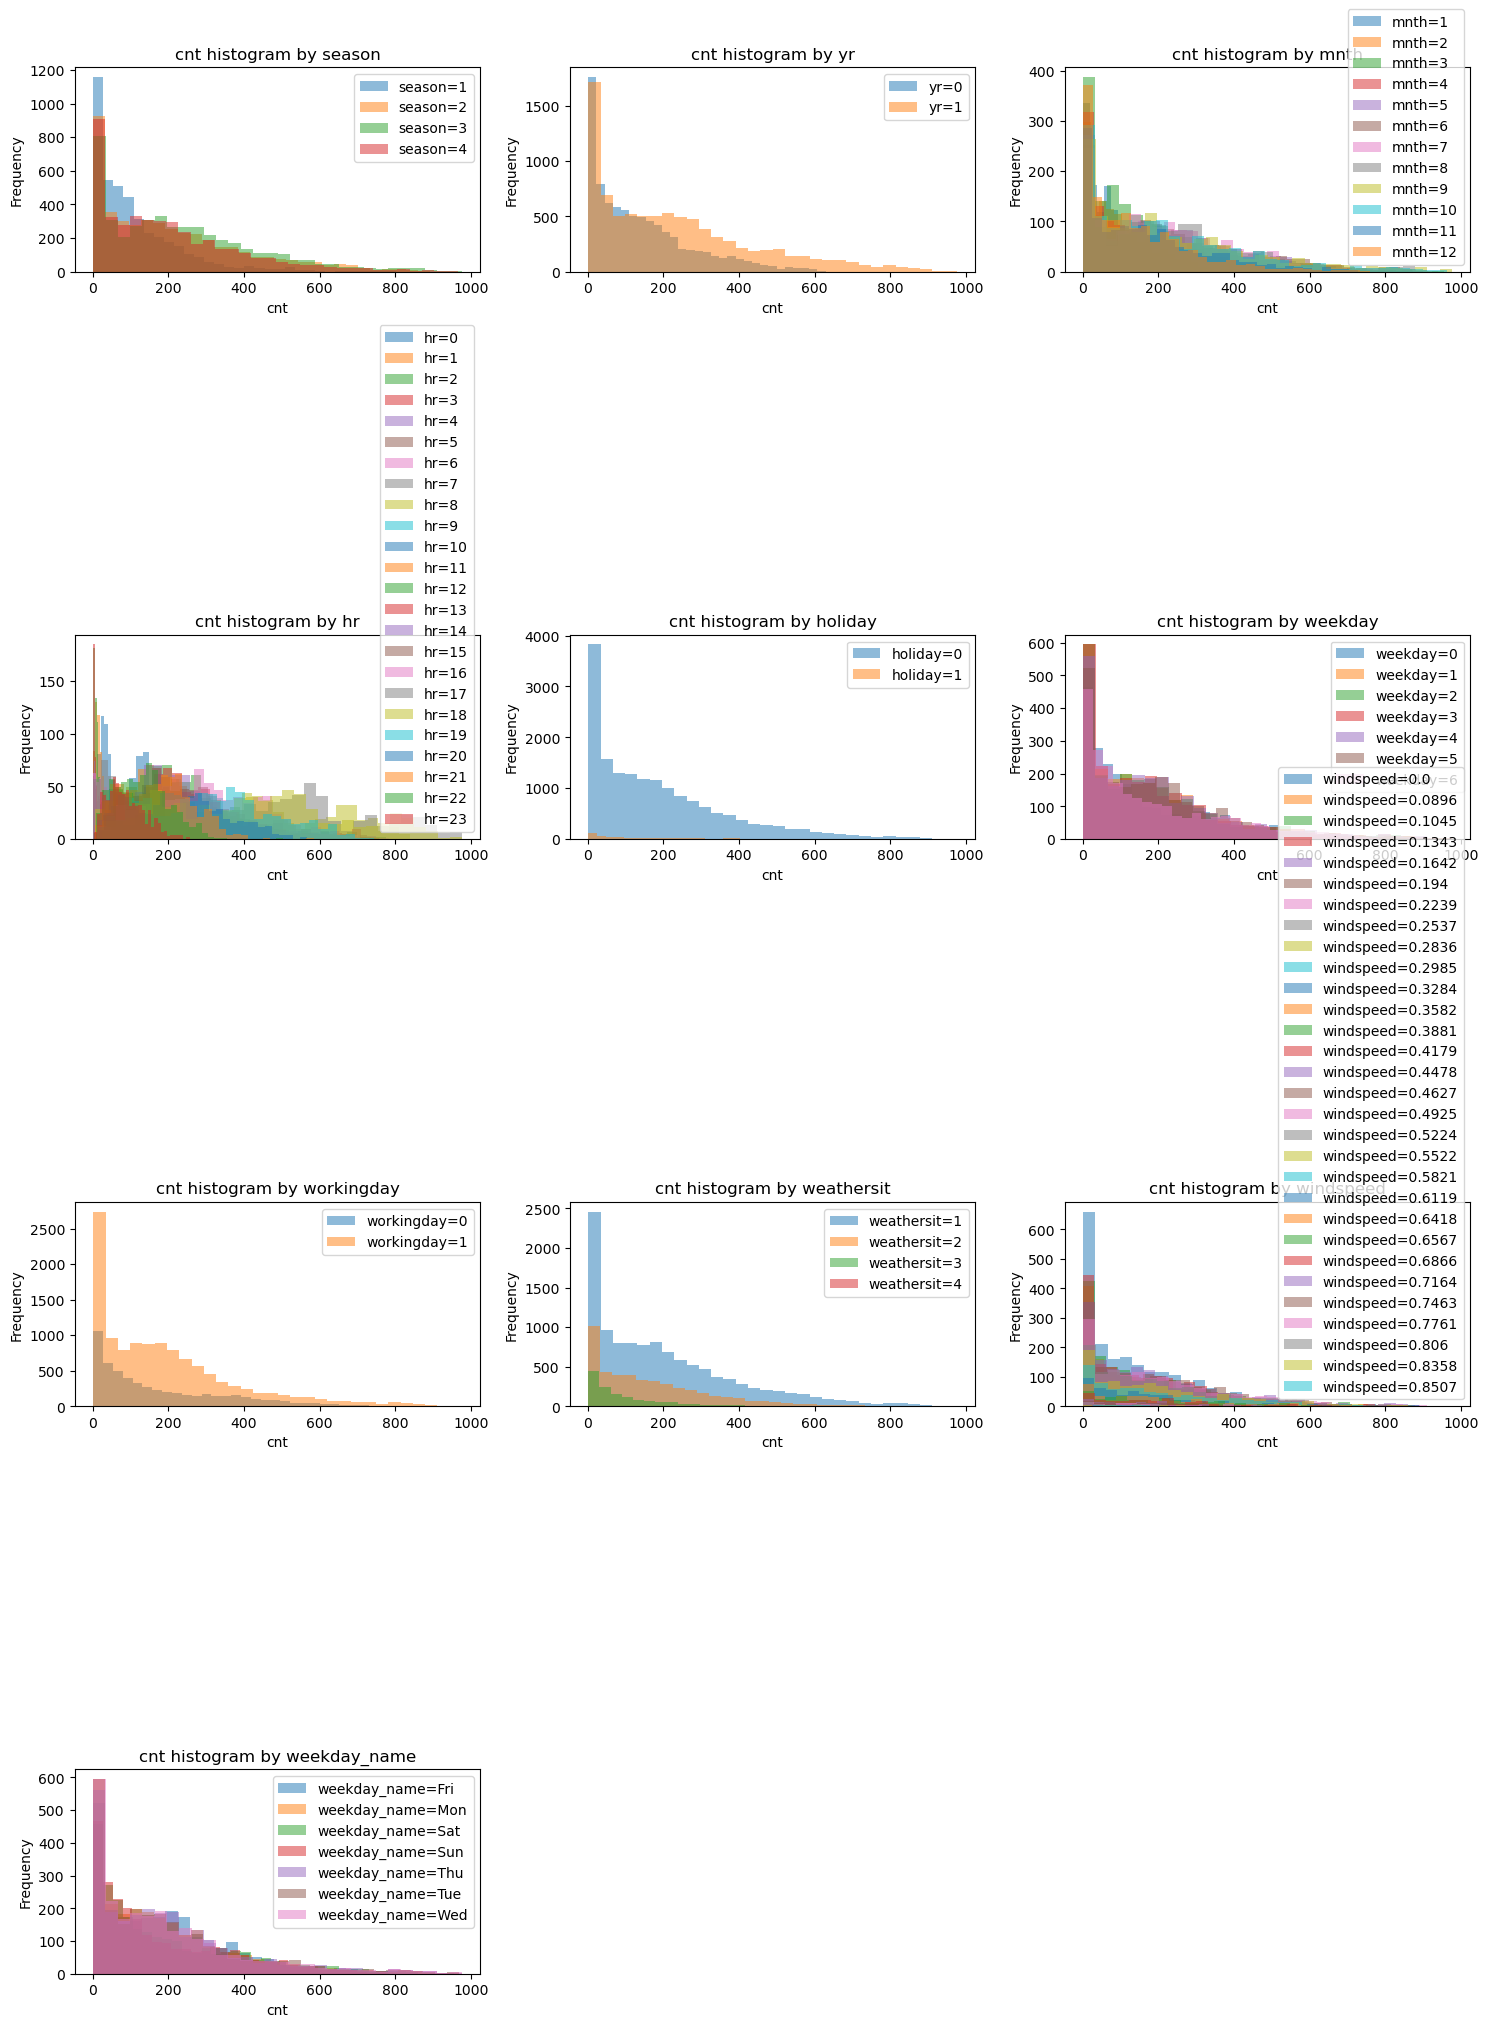

In [5]:
def plot_histograms_by_feature(df, target='cnt', max_unique=30):
    # Prepare to plot in a grid layout
    # Filter columns that have fewer unique values than max_unique
    cols_to_plot = [col for col in df.columns if col != target and df[col].nunique() <= max_unique]

    # Number of rows and columns in the grid (3 columns per row, adjust as necessary)
    n_cols = 3
    n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols  # Calculate rows to fit all plots
    
    # Set up the grid of subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()  # Flatten to make it easier to iterate over

    # Loop over each feature and plot its histogram in the corresponding axis
    for i, col in enumerate(cols_to_plot):
        for val in sorted(df[col].unique()):
            subset = df[df[col] == val]
            axes[i].hist(subset[target], bins=30, alpha=0.5, label=f'{col}={val}')
        axes[i].set_title(f'{target} histogram by {col}')
        axes[i].set_xlabel(target)
        axes[i].set_ylabel('Frequency')
        axes[i].legend()  # Optionally, you can add the legend

    # Hide any unused axes if the number of plots is less than the number of grid cells
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    # Adjust layout to avoid overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

# Call the function
plot_histograms_by_feature(df, target='cnt')



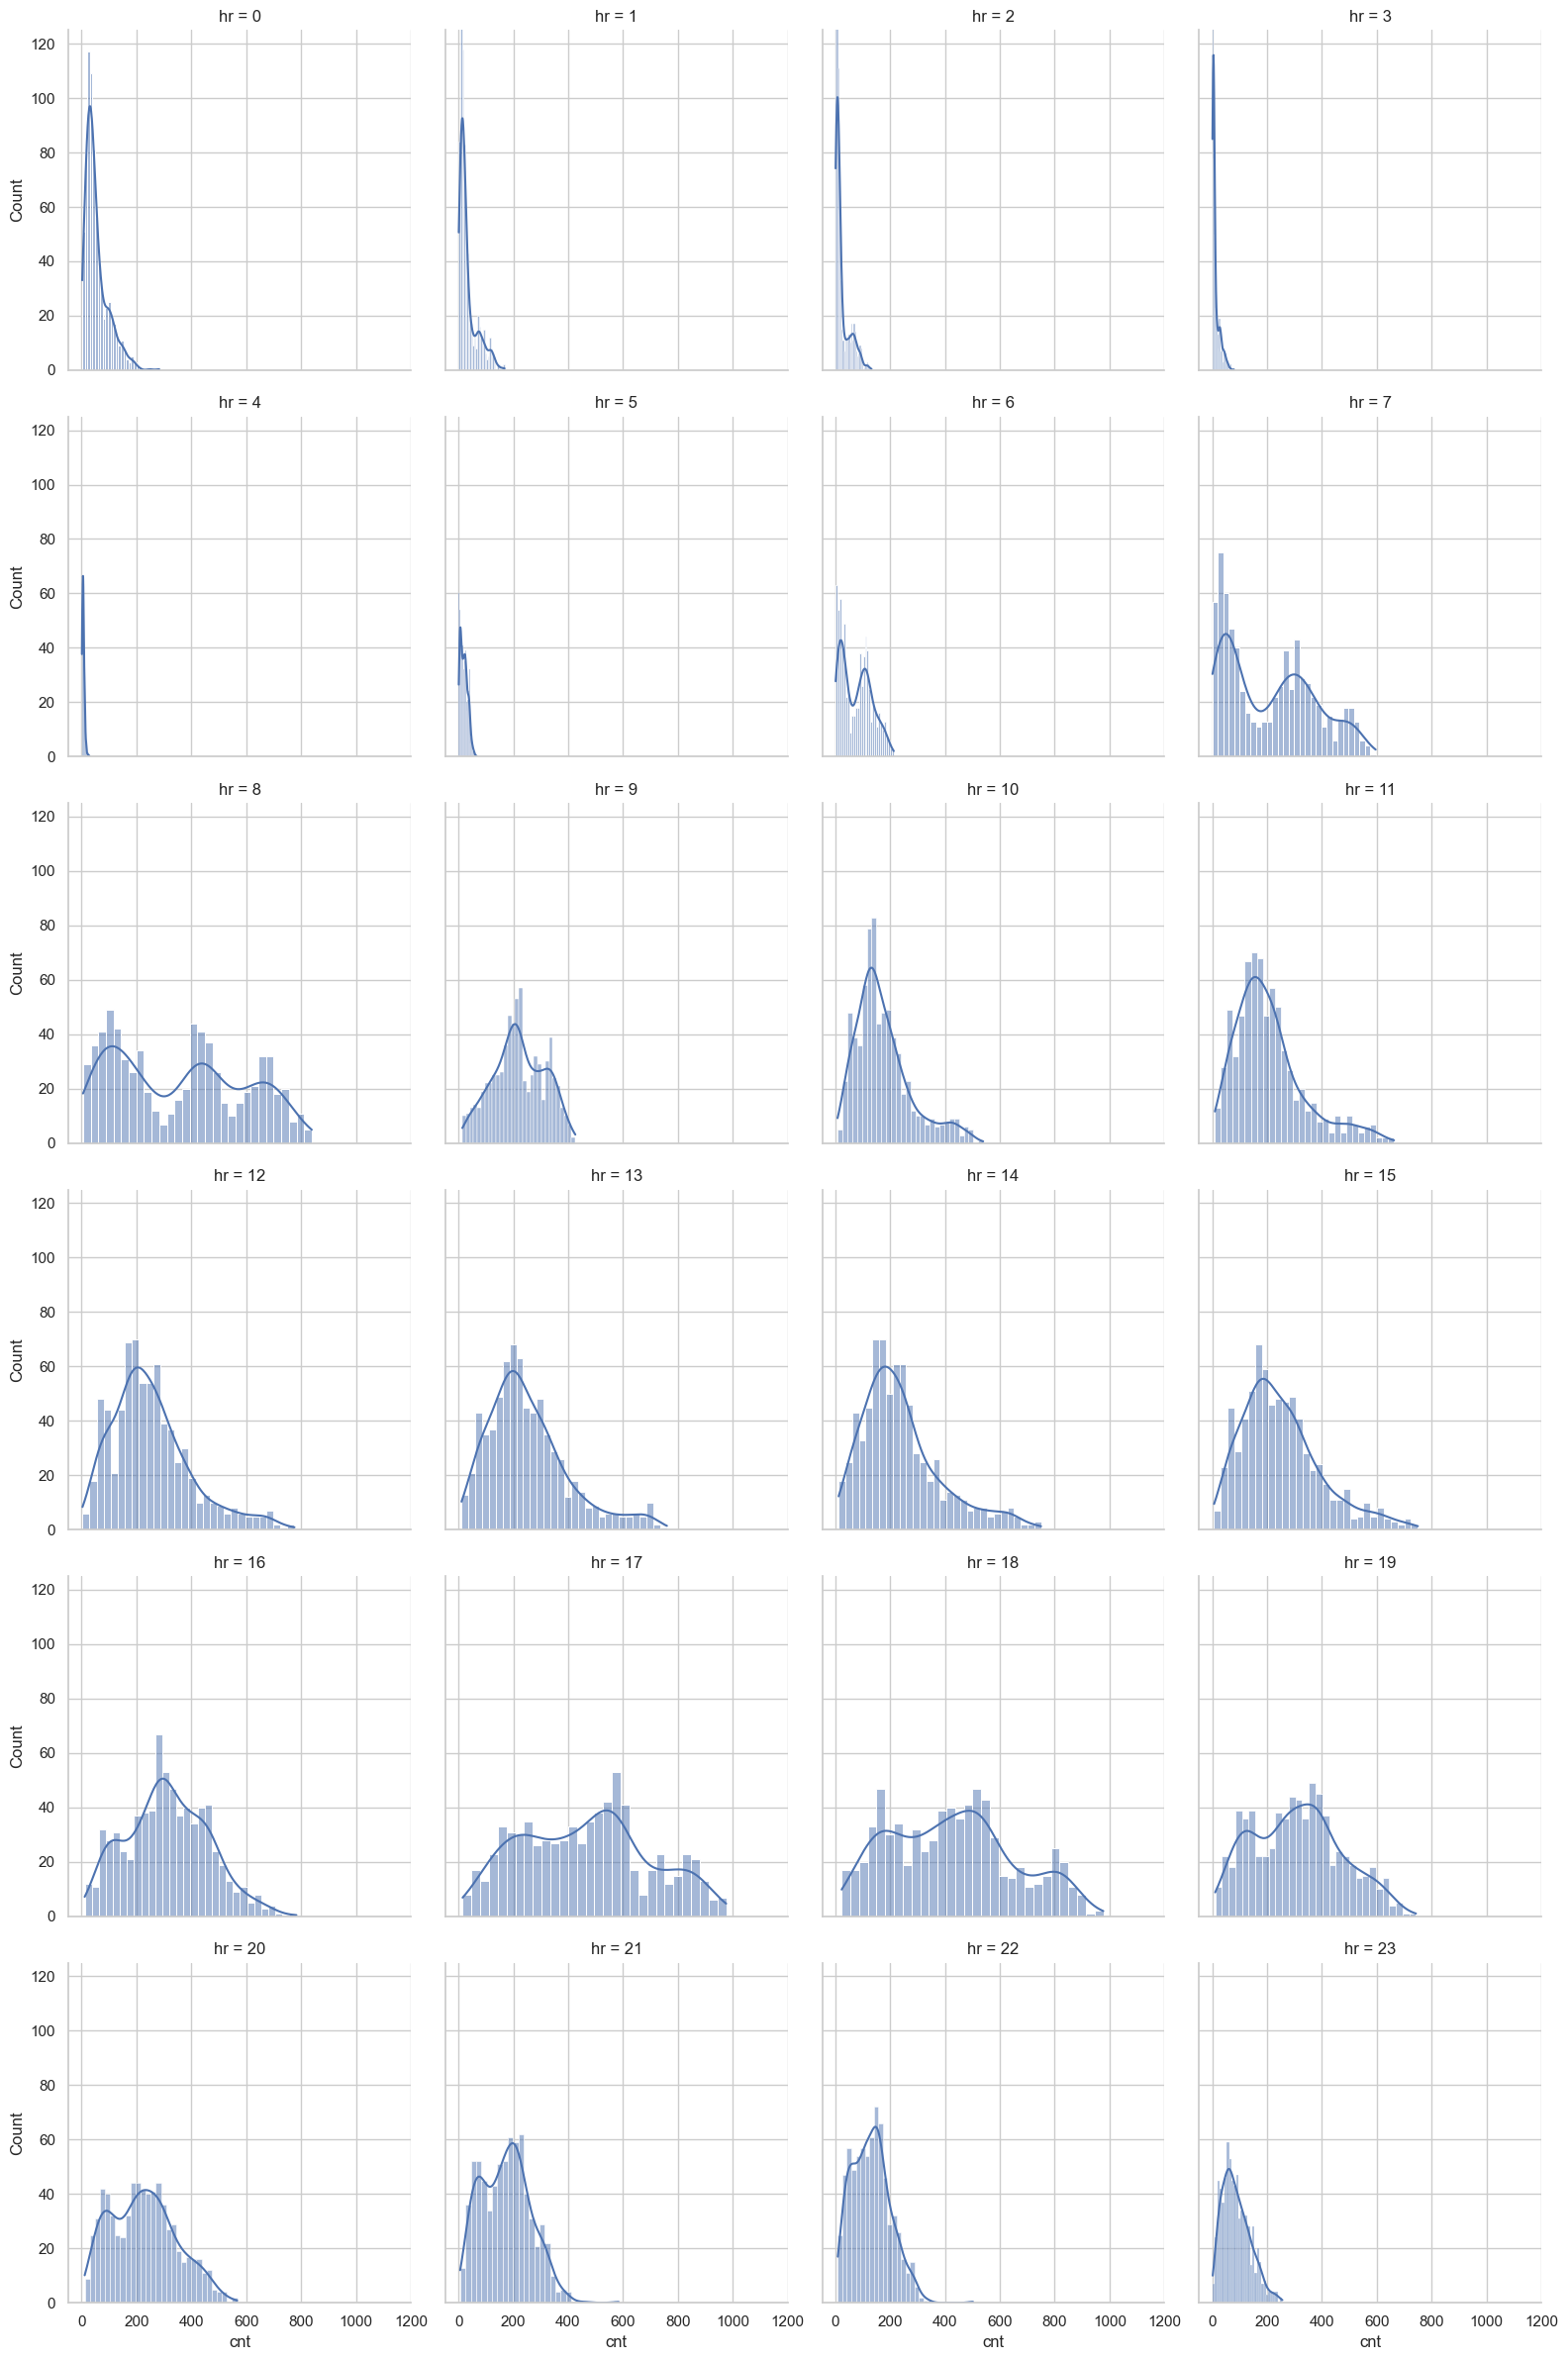

In [6]:
# Set the plot style
sns.set(style="whitegrid")

# Create a FacetGrid: one histogram per hour, 4 plots per row
g = sns.FacetGrid(df, col='hr', col_wrap=4, height=4)

# Map a histogram with kernel density estimate (KDE) over 'cnt' for each hour
g.map(sns.histplot, 'cnt', kde=True, bins=30)

g.set(ylim=(0, 125))
g.set(xticks=np.arange(0, 1201, 200))
plt.tight_layout()

# Show the plot
plt.show()

## Inspecting the multimodality in distribution over hours
1. Can we find another feature which seperates the modes?
    - The day will likely help
2. Casual/registered was measured but not included as a feature
3. Seems likely that the overall distribution is a mixture of distributions

In [7]:
print(df.columns.tolist())

['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'weekday_name']


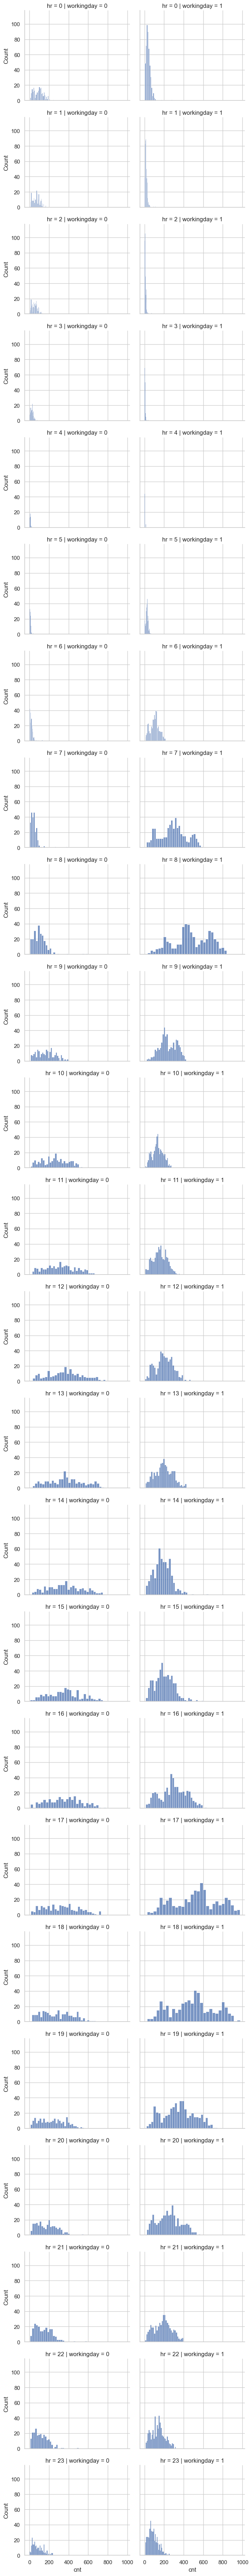

In [8]:
# Set style
sns.set(style="whitegrid")

# Create a FacetGrid with rows by workingday and columns by hour
g = sns.FacetGrid(df, row='hr', col='workingday', height=3, aspect=1.2)

# Map the histogram of 'cnt' to each subplot
g.map(sns.histplot, 'cnt', bins=30)

# Adjust layout to prevent label overlap
plt.tight_layout()
plt.show()

In [9]:
print(df.columns.tolist())

['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'weekday_name']


## Histrograming counts/feature

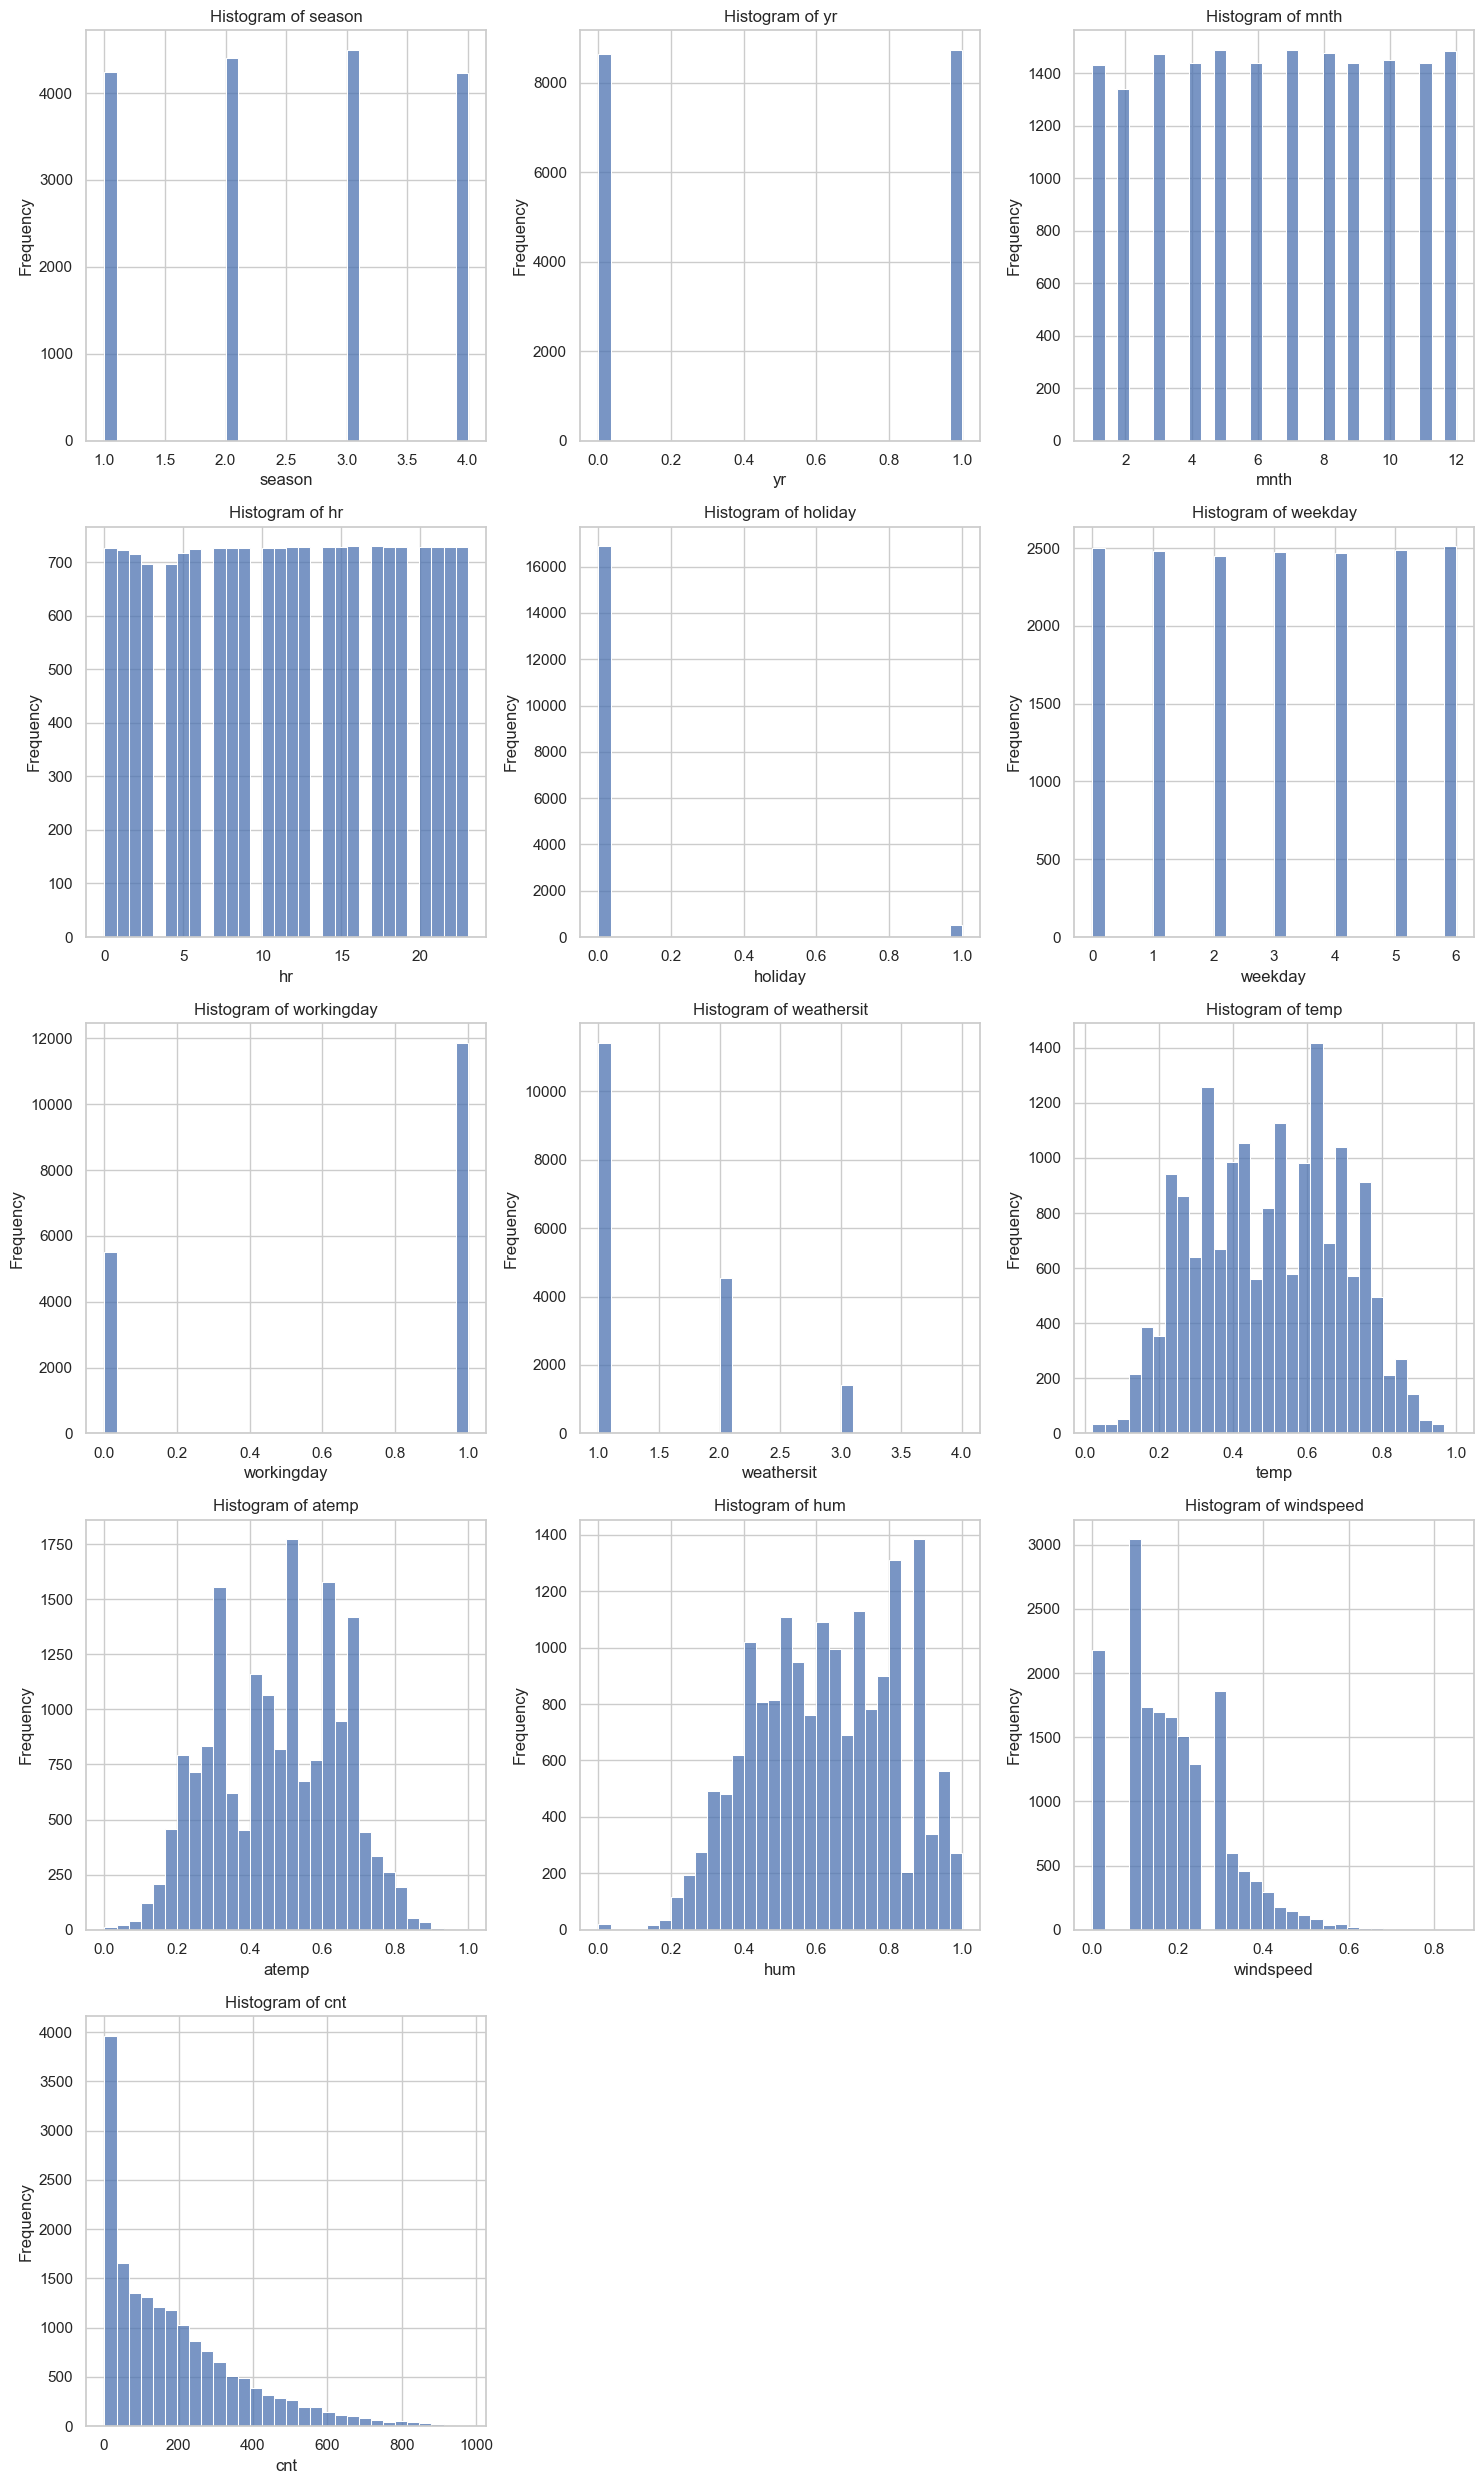

In [10]:
# Set up the plot grid
features = df.select_dtypes(include=['number']).columns  # Select numeric columns

# Number of rows and columns in the grid
n_rows = (len(features) + 2) // 3  # Automatically calculate rows for 3 columns
n_cols = 3

# Create a grid of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Flatten the axes array to make iteration easier
axes = axes.flatten()

# Loop through each feature and plot its histogram
for i, feature in enumerate(features):
    sns.histplot(df[feature], kde=False, ax=axes[i], bins=30)
    axes[i].set_title(f'Histogram of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

# Remove any unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Zero-inflated inspection

In [11]:
# Count the number of zeros in the 'cnt' column of df
num_zeros = (df['cnt'] == 0).sum()
print(f"Number of zeros in 'cnt': {num_zeros}")

Number of zeros in 'cnt': 0
